# Track C — 고령 취약계층 헬스케어 지역 군집화

| 항목 | 내용 |
|------|------|
| 분석 유형 | 비지도학습 — 군집화 (Unsupervised Clustering) |
| 군집 피처 | 고령화율 · 고령화율_변화 · 독거노인비율 · 비율_75-79세 · 비율_80-84세 · 비율_85세이상 · 인프라갭 · 포화도 · 수요공급갭지수 · 요양수요가속도 (10개) |
| 제외 피처 | 총인구수 · 65세이상인구 · 독거노인수_2018 · 시설수 (절대 원시값) |
| 데이터 | `df_analysis.csv` — 420개 행정동 |
| 알고리즘 | K-Means |
| 평가 지표 | WCSS · 실루엣 점수 · Davies-Bouldin 지수 |
| 시각화 | Elbow Curve · Silhouette Plot · 레이더 차트 · PCA 2D · Folium 지도 |

---
## 0. 환경 설정 및 데이터 로드

In [13]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

import folium

# 한글 폰트
KOREAN_FONTS = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
]
for fpath in KOREAN_FONTS:
    import os
    if os.path.exists(fpath):
        fm.fontManager.addfont(fpath)
        korean_name = fm.FontProperties(fname=fpath).get_name()
        plt.rcParams['font.family'] = [korean_name, 'DejaVu Sans']
        break

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 120

# 재현성을 위해서 SEED 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [14]:
df = pd.read_csv('data/df_analysis.csv', encoding='utf-8-sig')

print(f'행정동 수: {len(df)}개')
print(f'컬럼: {df.columns.tolist()}')
display(df.head(3))

행정동 수: 420개
컬럼: ['행정동코드', '행정동명', '시군구명', '자치구명', '연도', '총인구수', '65세이상인구', '독거노인수_2018', '고령화율', '고령화율_변화', '독거노인비율', '비율_75-79세', '비율_80-84세', '비율_85세이상', '인프라갭', '포화도', '시설수', '수요공급갭지수', '요양수요가속도']


,행정동코드,행정동명,시군구명,자치구명,연도,총인구수,65세이상인구,독거노인수_2018,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수,요양수요가속도
0,1111051500,청운효자동,종로구,종로구,2023,11605,2144,448.0,18.47,0.42,29.90,20.81,16.99,11.99,2144.00,0.961,8,302.6852,35.820
1,1111053000,사직동,종로구,종로구,2023,9120,1808,1822.0,19.82,1.04,30.75,18.21,17.65,15.16,602.67,0.961,8,212.4236,-24.336
2,1111054000,삼청동,종로구,종로구,2023,2322,589,167.0,25.37,0.67,32.77,18.37,15.48,14.29,294.50,0.961,8,75.4391,14.470


---
## 1. 탐색적 데이터 분석 (EDA)

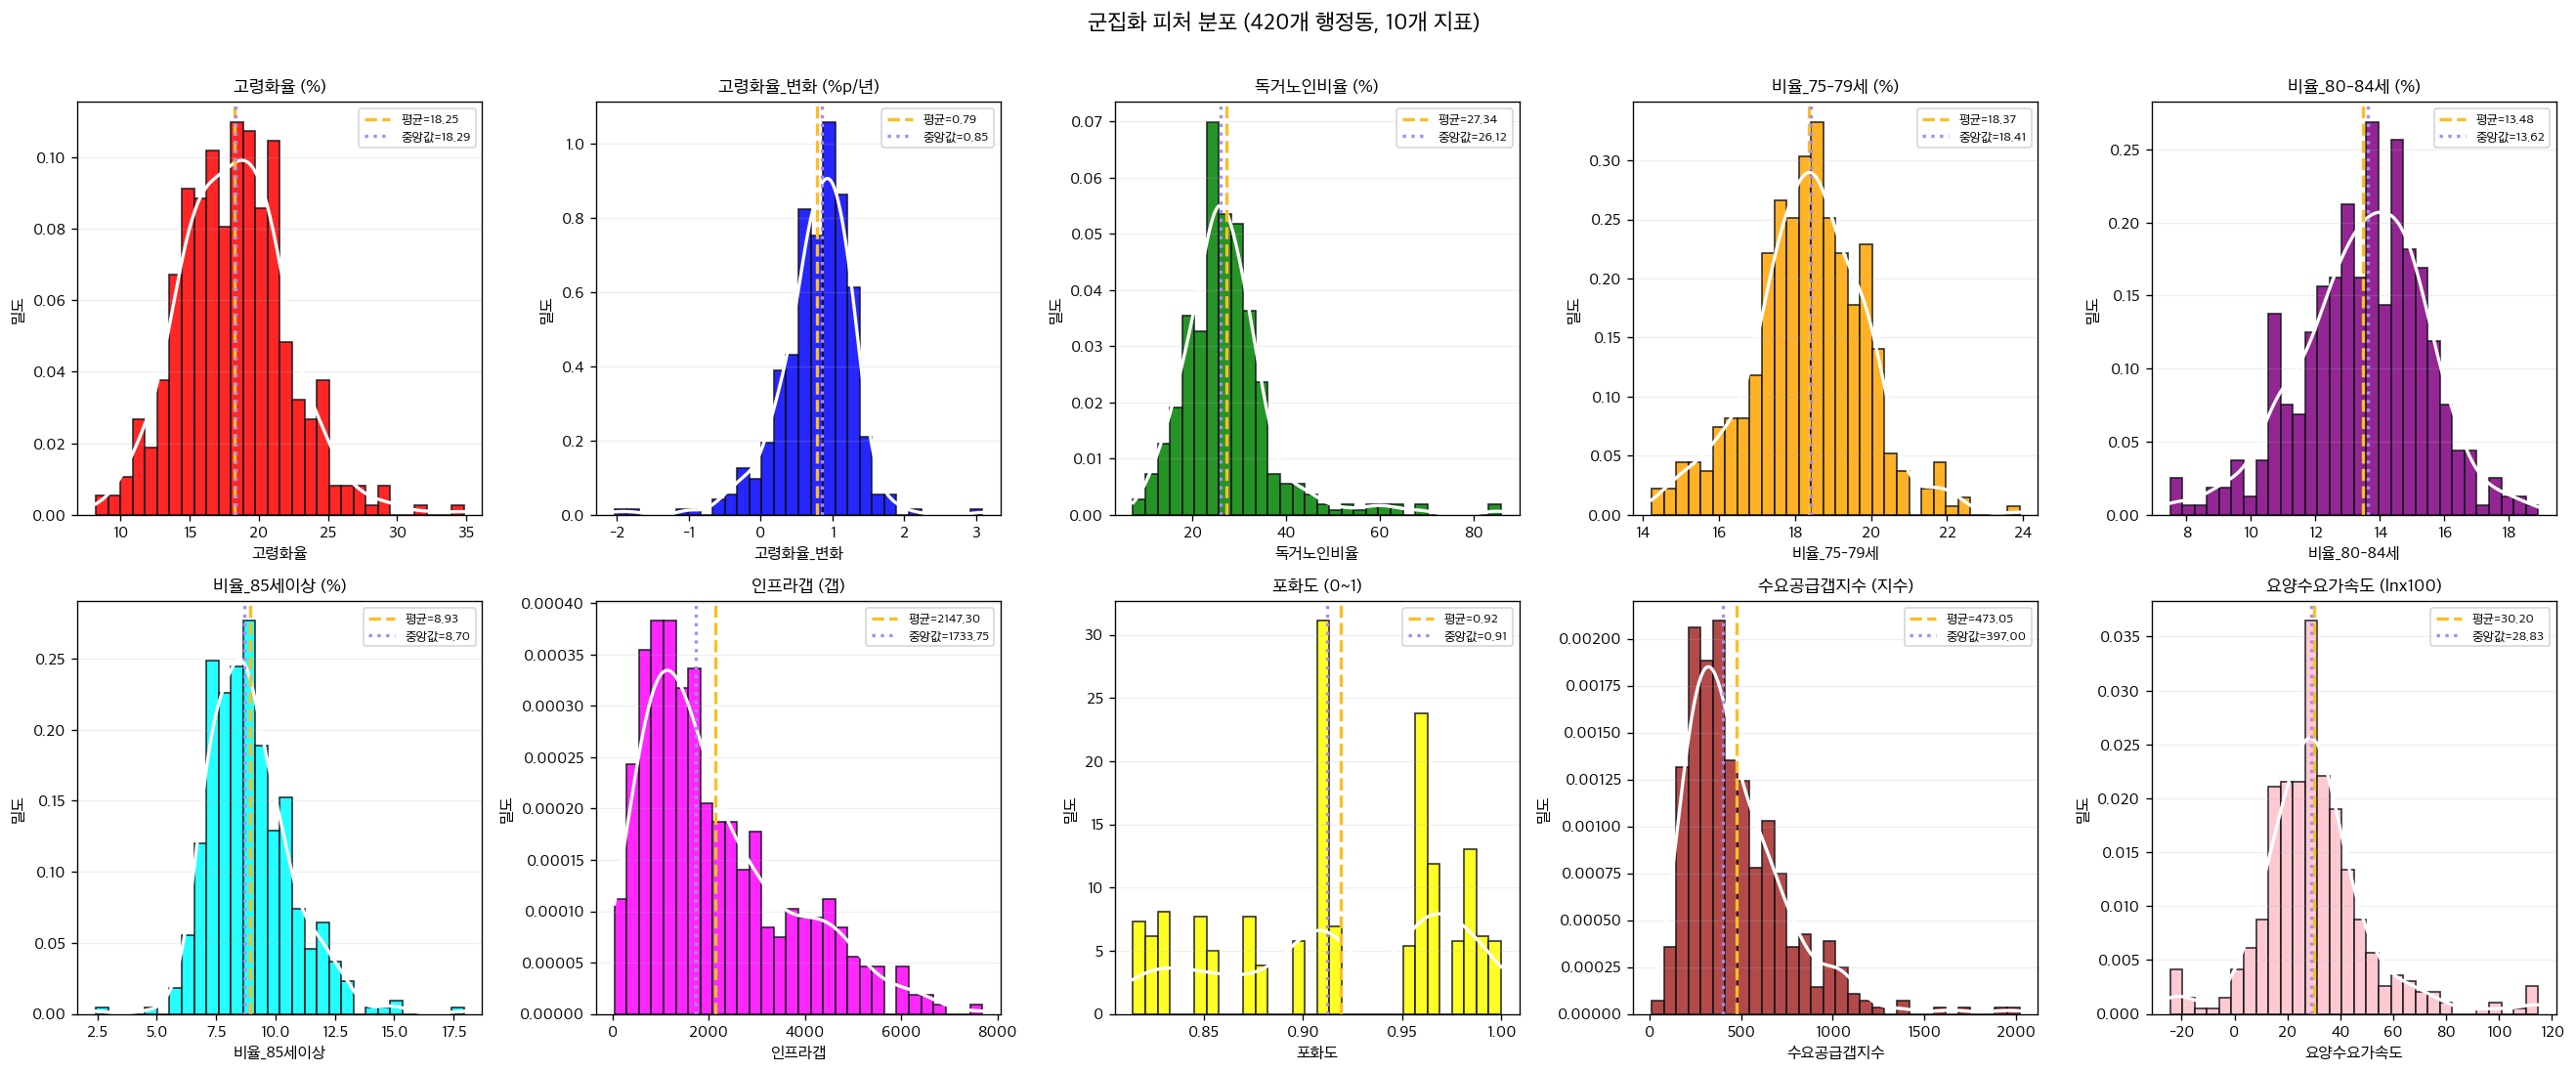

,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,수요공급갭지수,요양수요가속도
count,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000
mean,18.248,0.785,27.344,18.370,13.480,8.929,2147.297,0.919,473.052,30.197
std,3.855,0.510,9.758,1.477,1.945,1.753,1514.797,0.056,279.492,20.941
min,8.210,-2.030,7.320,14.240,7.490,2.440,41.000,0.814,9.824,-24.336
25%,15.600,0.540,21.995,17.545,12.308,7.700,1013.700,0.875,277.350,19.398
50%,18.285,0.855,26.125,18.410,13.625,8.695,1733.750,0.912,396.999,28.825
75%,20.652,1.110,30.928,19.335,14.780,9.855,3000.000,0.964,614.187,38.175
max,34.830,3.090,85.920,23.900,18.910,17.940,7688.000,1.000,2021.354,114.752


In [15]:
CLUSTER_FEATS = [
    '고령화율', '고령화율_변화', '독거노인비율',
    '비율_75-79세', '비율_80-84세', '비율_85세이상',
    '인프라갭', '포화도', '수요공급갭지수', '요양수요가속도'
]

# 시각화
from scipy.stats import gaussian_kde

feat_units = [
    '(%)', '(%p/년)', '(%)',
    '(%)', '(%)', '(%)',
    '(갭)', '(0~1)', '(지수)', '(lnx100)'
]
# 시각화를 위한 컬러 설정 : 10개의 지표에 각각 다른 색 할당
feat_colors = [
    'red', 'blue', 'green', 'orange', 'purple',
    'cyan', 'magenta', 'yellow', 'brown', 'pink'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, (feat, color, unit) in enumerate(zip(CLUSTER_FEATS, feat_colors, feat_units)):
    ax = axes[i]
    data = df[feat].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='#0f1117', alpha=0.85, density=True)
    kde = gaussian_kde(data)
    xr = np.linspace(data.min(), data.max(), 200)
    ax.plot(xr, kde(xr), color='white', lw=2)
    ax.axvline(data.mean(), color='#fbbf24', lw=2, ls='--', label=f'평균={data.mean():.2f}')
    ax.axvline(data.median(), color='#a78bfa', lw=2, ls=':', label=f'중앙값={data.median():.2f}')
    ax.set_title(f'{feat} {unit}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('군집화 피처 분포 (420개 행정동, 10개 지표)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
display(df[CLUSTER_FEATS].describe().round(3))

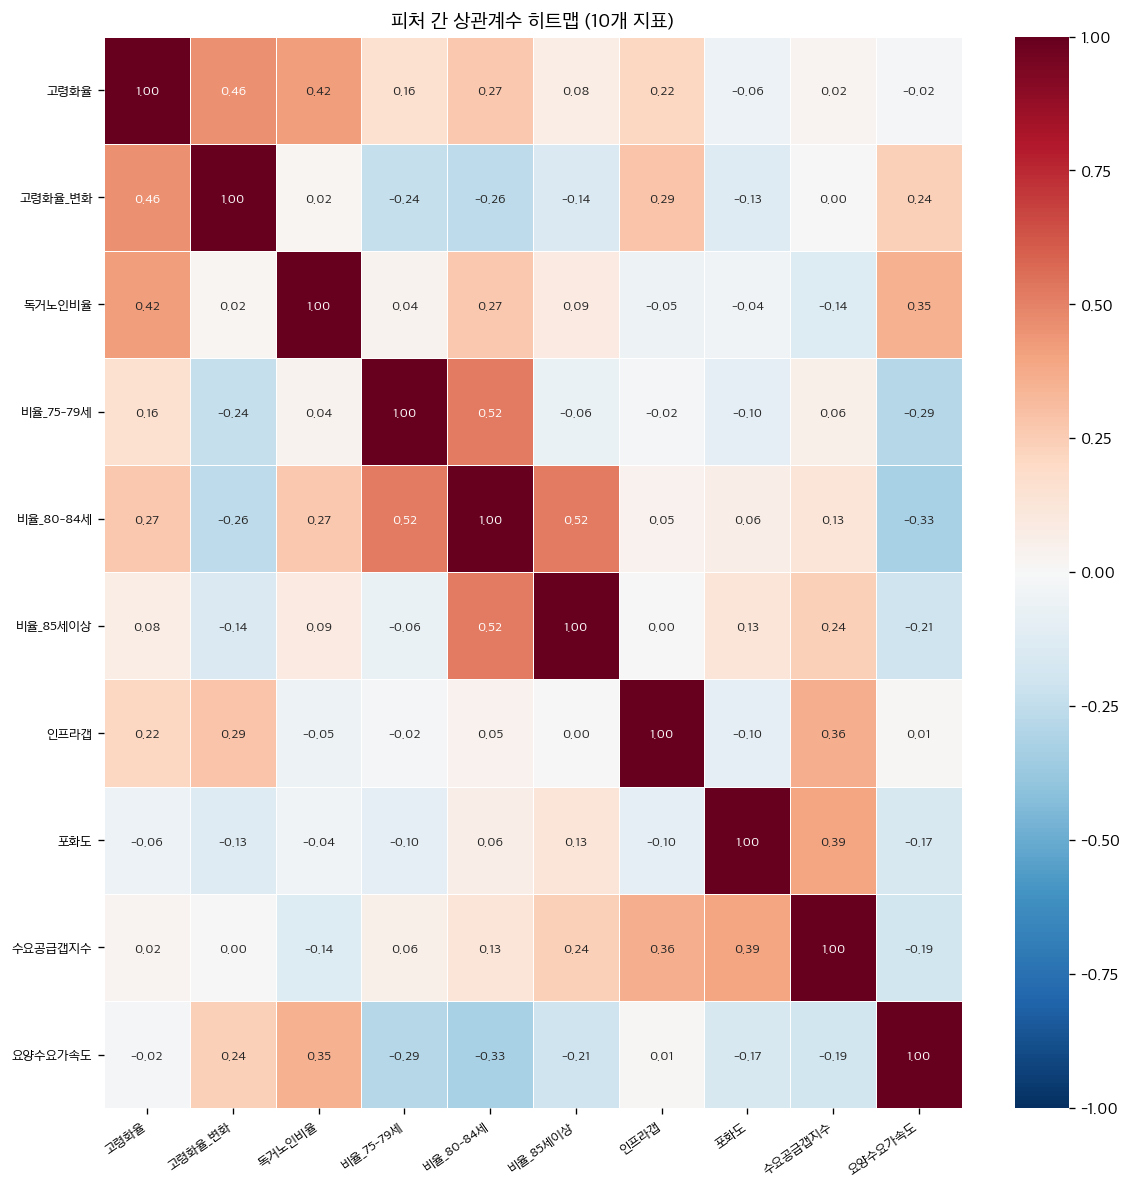

In [16]:
# 상관계수 히트맵 — 10개 피처 전체
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

corr = df[CLUSTER_FEATS].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    ax=axes, linewidths=0.5, annot_kws={'size': 8}
)
axes.set_title('피처 간 상관계수 히트맵 (10개 지표)', fontsize=12, fontweight='bold')
axes.set_xticklabels(axes.get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes.set_yticklabels(axes.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. 피처 표준화

In [17]:
X_raw = df[CLUSTER_FEATS].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATS, index=df.index)

print(f'군집화 피처: {CLUSTER_FEATS}')
print(f'표준화 전 범위:')
for feat in CLUSTER_FEATS:
    print(f'  {feat}: [{df[feat].min():.2f}, {df[feat].max():.2f}]')
print(f'표준화 후 평균: {X_scaled.mean(axis=0).round(4)}')
print(f'표준화 후 std:  {X_scaled.std(axis=0).round(4)}')

군집화 피처: ['고령화율', '고령화율_변화', '독거노인비율', '비율_75-79세', '비율_80-84세', '비율_85세이상', '인프라갭', '포화도', '수요공급갭지수', '요양수요가속도']
표준화 전 범위:
  고령화율: [8.21, 34.83]
  고령화율_변화: [-2.03, 3.09]
  독거노인비율: [7.32, 85.92]
  비율_75-79세: [14.24, 23.90]
  비율_80-84세: [7.49, 18.91]
  비율_85세이상: [2.44, 17.94]
  인프라갭: [41.00, 7688.00]
  포화도: [0.81, 1.00]
  수요공급갭지수: [9.82, 2021.35]
  요양수요가속도: [-24.34, 114.75]
표준화 후 평균: [-0.  0.  0.  0.  0. -0. -0.  0.  0.  0.]
표준화 후 std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 3. K-Means 군집화
### 3-1. 최적 K 선정 — Elbow / Silhouette / Davies-Bouldin

  K= 2: WCSS=  3591.9, 실루엣=0.1365, DB=2.2595
  K= 3: WCSS=  3162.8, 실루엣=0.1466, DB=1.9744
  K= 4: WCSS=  2856.6, 실루엣=0.1492, DB=1.8151
  K= 5: WCSS=  2626.0, 실루엣=0.1536, DB=1.6948
  K= 6: WCSS=  2471.5, 실루엣=0.1359, DB=1.7967
  K= 7: WCSS=  2340.8, 실루엣=0.1262, DB=1.7691
  K= 8: WCSS=  2225.3, 실루엣=0.1291, DB=1.6870
  K= 9: WCSS=  2144.4, 실루엣=0.1307, DB=1.6358
  K=10: WCSS=  2083.1, 실루엣=0.1228, DB=1.6450

실루엣 기준 최적 K: 5


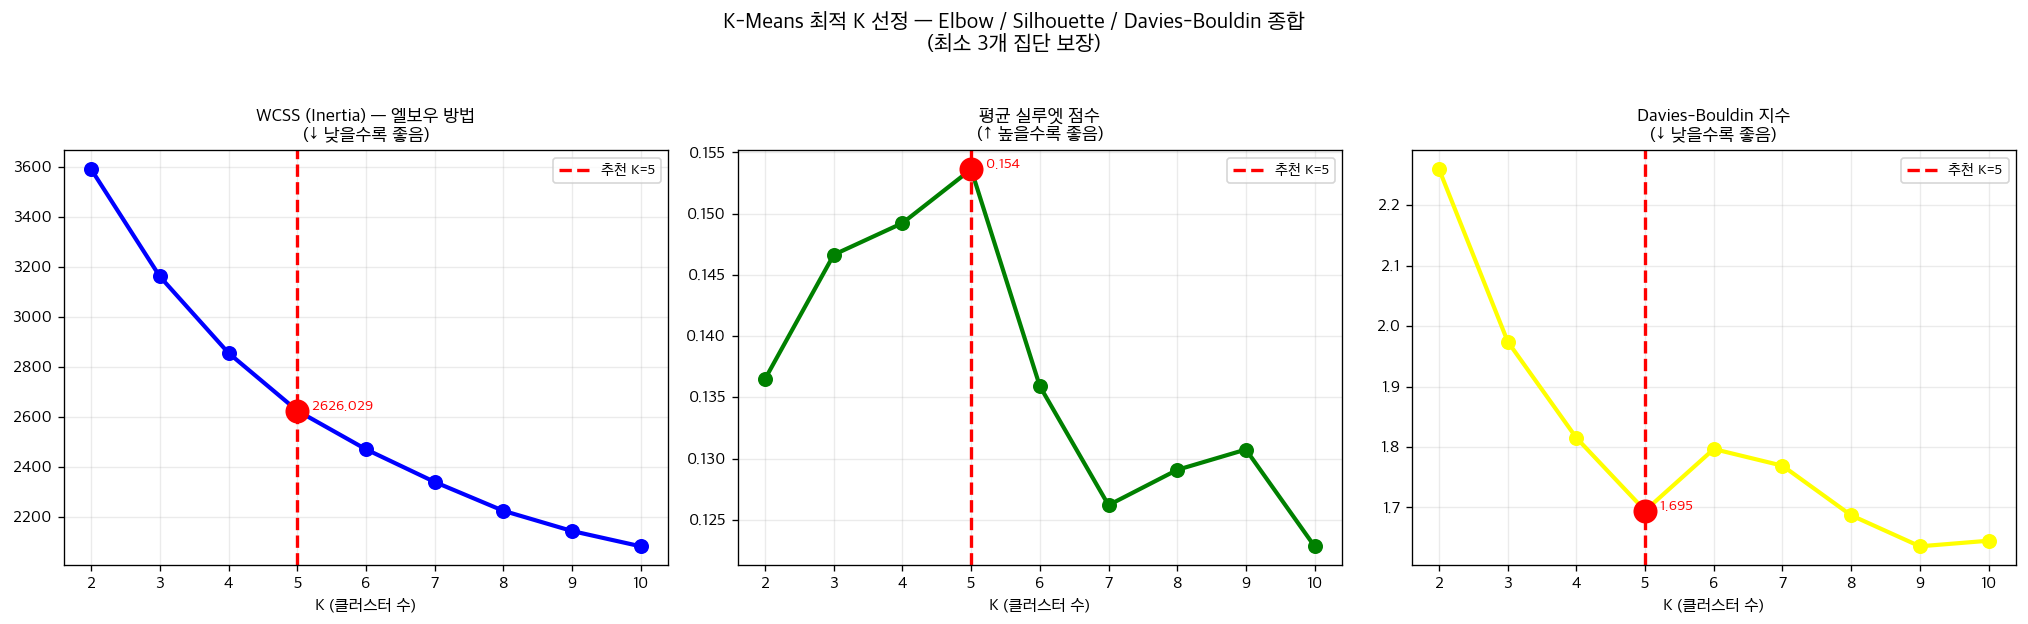

In [18]:
K_RANGE = range(2, 11)
wcss_list, sil_list, db_list = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, labels))
    db_list.append(davies_bouldin_score(X_scaled, labels))
    print(f'  K={k:2d}: WCSS={km.inertia_:8.1f}, 실루엣={sil_list[-1]:.4f}, DB={db_list[-1]:.4f}')

k_vals = list(K_RANGE)
K_OPTIMAL = k_vals[np.argmax(sil_list)]
print(f'\n실루엣 기준 최적 K: {K_OPTIMAL}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_configs = [
    (wcss_list, 'WCSS (Inertia) — 엘보우 방법','blue', '↓ 낮을수록 좋음'),
    (sil_list, '평균 실루엣 점수', 'green', '↑ 높을수록 좋음'),
    (db_list, 'Davies-Bouldin 지수', 'yellow', '↓ 낮을수록 좋음'),
]
for ax, (vals, title, color, hint) in zip(axes, plot_configs):
    ax.plot(k_vals, vals, 'o-', color=color, lw=2.5, markersize=8, zorder=3)
    ax.axvline(K_OPTIMAL, color='red', ls='--', lw=2, label=f'추천 K={K_OPTIMAL}', zorder=2)
    opt_val = vals[k_vals.index(K_OPTIMAL)]
    ax.scatter([K_OPTIMAL], [opt_val], s=180, color='red', zorder=5)
    ax.text(K_OPTIMAL + 0.1, opt_val, f'  {opt_val:.3f}', fontsize=9, color='red')
    ax.set_xticks(k_vals)
    ax.set_xlabel('K (클러스터 수)')
    ax.set_title(f'{title}\n({hint})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.suptitle('K-Means 최적 K 선정 — Elbow / Silhouette / Davies-Bouldin 종합\n(최소 3개 집단 보장)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

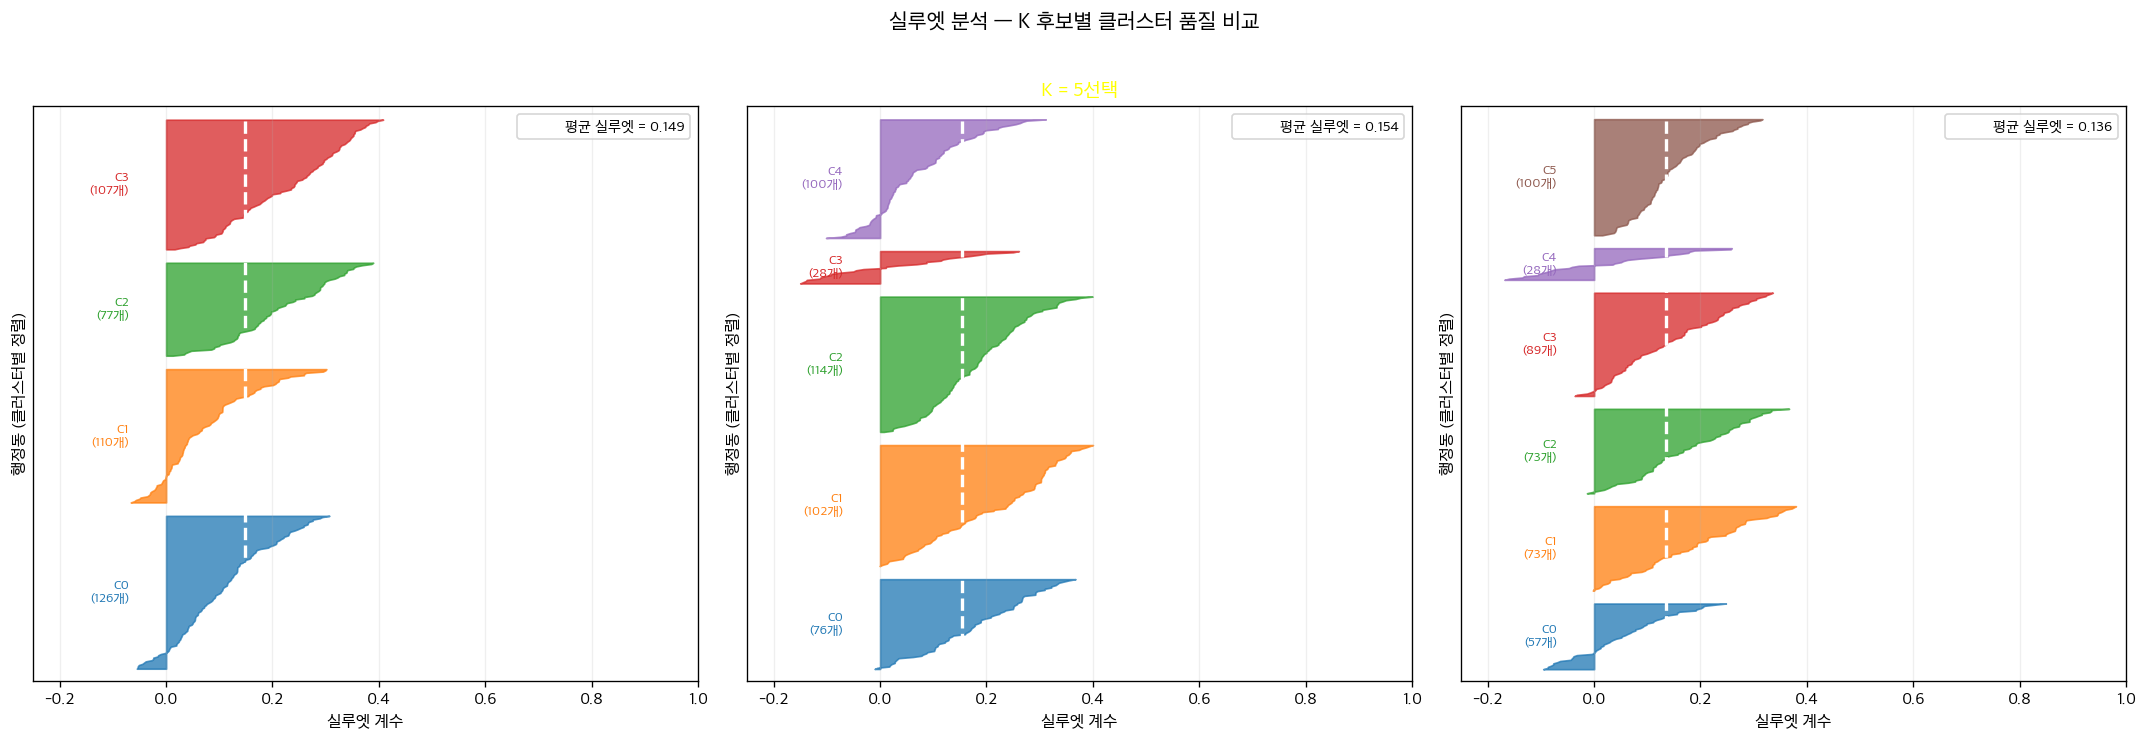

In [19]:
# 실루엣 세부 분석 — 후보 K값 3개 비교
k_candidates = sorted(set([
    max(2, K_OPTIMAL - 1),
    K_OPTIMAL,
    min(10, K_OPTIMAL + 1)
]))

fig, axes = plt.subplots(1, len(k_candidates), figsize=(6*len(k_candidates), 6))
if len(k_candidates) == 1:
    axes = [axes]

tab_colors = plt.cm.tab10.colors

for ax, K_cand in zip(axes, k_candidates):
    km_c = KMeans(n_clusters=K_cand, n_init=20, random_state=RANDOM_STATE)
    labels_c = km_c.fit_predict(X_scaled)
    sil_vals = silhouette_samples(X_scaled, labels_c)
    avg_sil  = silhouette_score(X_scaled, labels_c)

    y_lower = 10
    for k in range(K_cand):
        cluster_sil = np.sort(sil_vals[labels_c == k])
        y_upper = y_lower + cluster_sil.shape[0]
        color = tab_colors[k % 10]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.75)
        ax.text(-0.07, y_lower + cluster_sil.shape[0]/2,
                f'C{k}\n({cluster_sil.shape[0]}개)',
                ha='right', va='center', fontsize=8, fontweight='bold', color=color)
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='white', ls='--', lw=2, label=f'평균 실루엣 = {avg_sil:.3f}')
    ax.set_xlim([-0.25, 1.0]); ax.set_ylim([0, y_lower])
    ax.set_yticks([]); ax.set_xlabel('실루엣 계수'); ax.set_ylabel('행정동 (클러스터별 정렬)')
    is_opt = K_cand == K_OPTIMAL
    ax.set_title(f'K = {K_cand}' + ('선택' if is_opt else ''),
                 fontsize=12, fontweight='bold', color='yellow' if is_opt else 'white')
    ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.2)

plt.suptitle('실루엣 분석 — K 후보별 클러스터 품질 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3-2. 최종 K-Means 모델

In [20]:
km_final = KMeans(n_clusters=K_OPTIMAL, n_init=50, random_state=RANDOM_STATE)
df['cluster_km'] = km_final.fit_predict(X_scaled)

# 히트맵(Z-score) 분석 기반 직접 라벨링 — 취약도 합성 점수 미사용
# C0: 비율_85세이상↑, 포화도↑, 수요공급갭↑, 요양수요가속도↓
# C1: 고령화율↑, 고령화율_변화↑, 인프라갭↑↑, 포화도↓
# C2: 고령화율_변화↓(감소), 비율_75-79세↑, 인프라갭↓, 요양수요가속도↓
# C3: 모든 고령지표↓, 요양수요가속도 소폭↑
# C4: 고령화율↑, 독거노인비율↑, 요양수요가속도↑
cluster_names = {
    0: '초고령·인프라포화',
    1: '고령화가속·인프라갭',
    2: '고령화안정·인프라충족',
    3: '저고령·수요태동',
    4: '고령독거·수요폭증',
}
df['cluster_label'] = df['cluster_km'].map(cluster_names)

# 시각화 정렬: 요양수요가속도 클러스터 평균 오름차순 (낮은 수요->높은 수요)
acc_means = df.groupby('cluster_km')['요양수요가속도'].mean()
sorted_clusters = acc_means.sort_values().index.tolist()

cluster_sizes = df['cluster_km'].value_counts().sort_index()
# 색상: 수요 낮음(파랑) - 초록 - 노랑 - 주황 - 위험(빨강)
PALETTE = ['blue', 'green', 'yellow', 'orange', 'red']

print(f'K_OPTIMAL = {K_OPTIMAL}')
print(f'\n[요양수요가속도 오름차순]')
for cid in sorted_clusters:
    print(f'C{cid} [{cluster_names[cid]}]: {cluster_sizes[cid]}개  |  요양수요가속도 평균 = {acc_means[cid]:.2f}')
print(f'\n실루엣: {silhouette_score(X_scaled, df["cluster_km"]):.4f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X_scaled, df["cluster_km"]):.4f}')

K_OPTIMAL = 5

[요양수요가속도 오름차순]
C0 [초고령·인프라포화]: 76개  |  요양수요가속도 평균 = 18.98
C2 [고령화안정·인프라충족]: 103개  |  요양수요가속도 평균 = 22.35
C1 [고령화가속·인프라갭]: 115개  |  요양수요가속도 평균 = 28.10
C3 [저고령·수요태동]: 100개  |  요양수요가속도 평균 = 40.00
C4 [고령독거·수요폭증]: 26개  |  요양수요가속도 평균 = 65.67

실루엣: 0.1540
Davies-Bouldin: 1.6929


---
## 4. 클러스터 프로파일 시각화

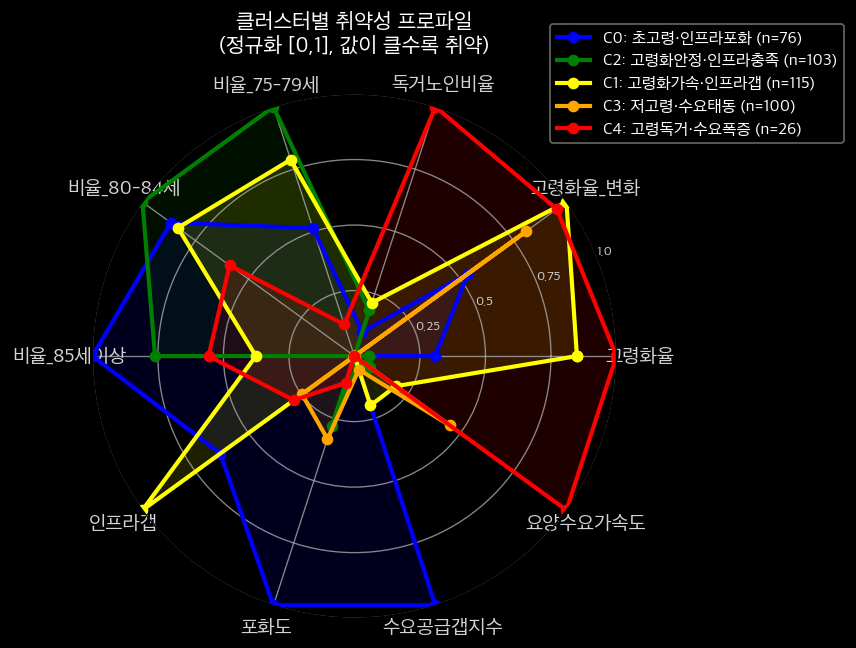

In [21]:
# 레이더 차트
cluster_means_raw = df.groupby('cluster_km')[CLUSTER_FEATS].mean()
cmin = cluster_means_raw.min(); cmax = cluster_means_raw.max()
cluster_means_norm = (cluster_means_raw - cmin) / (cmax - cmin + 1e-9)

N = len(CLUSTER_FEATS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

for i, cid in enumerate(sorted_clusters):
    color = PALETTE[i % len(PALETTE)]
    values = cluster_means_norm.loc[cid, CLUSTER_FEATS].values.tolist()
    values += values[:1]
    n_dong = cluster_sizes.get(cid, 0)
    ax.plot(angles, values, 'o-', lw=2.5, color=color,
            label=f'C{cid}: {cluster_names.get(cid,"")} (n={n_dong})')
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(CLUSTER_FEATS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='gray')
ax.grid(color='darkgray', alpha=0.8)
ax.set_title('클러스터별 취약성 프로파일\n(정규화 [0,1], 값이 클수록 취약)',
             fontsize=13, fontweight='bold', pad=25, color='white')
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10,
          facecolor='black', edgecolor='gray', labelcolor='white')
ax.tick_params(colors='lightgray')
plt.tight_layout()
plt.show()

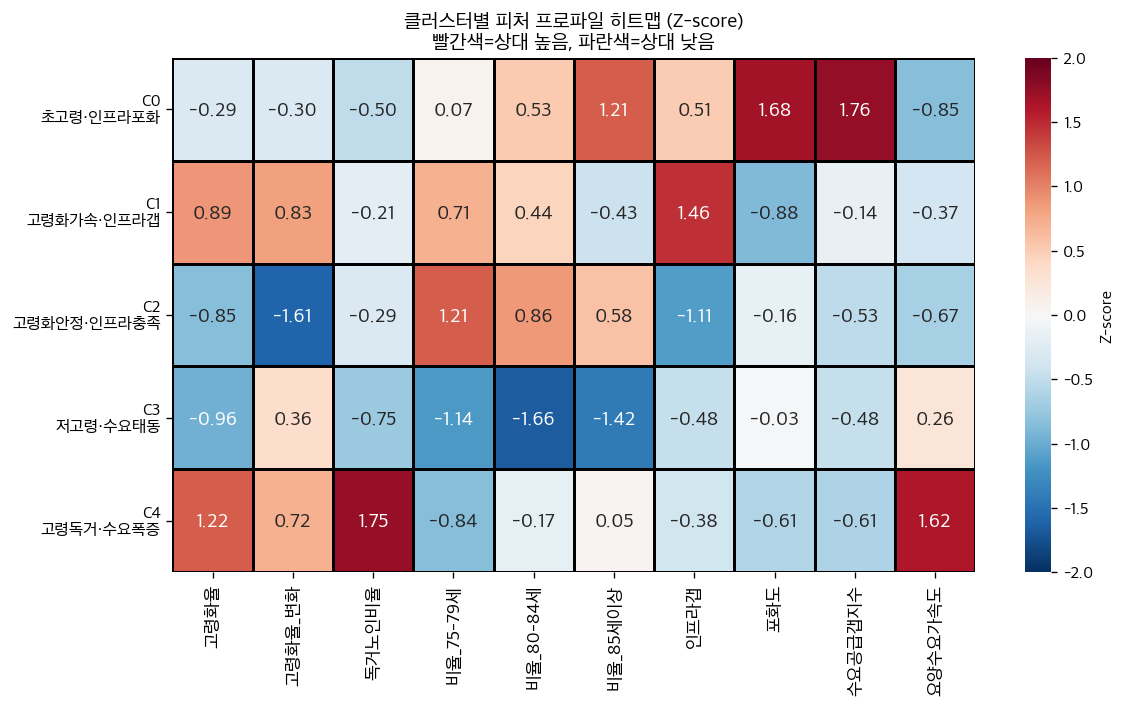

In [22]:
# 클러스터 프로파일 히트맵
cluster_means_z = df.groupby('cluster_km')[CLUSTER_FEATS].mean()
cluster_means_z_norm = cluster_means_z.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9))
cluster_means_z_norm.index = [f'C{cid}\n{cluster_names.get(cid,"")}' for cid in cluster_means_z_norm.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cluster_means_z_norm, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=1.5, linecolor='black',
    ax=ax, annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Z-score'}, vmin=-2, vmax=2
)
ax.set_title('클러스터별 피처 프로파일 히트맵 (Z-score)\n빨간색=상대 높음, 파란색=상대 낮음',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

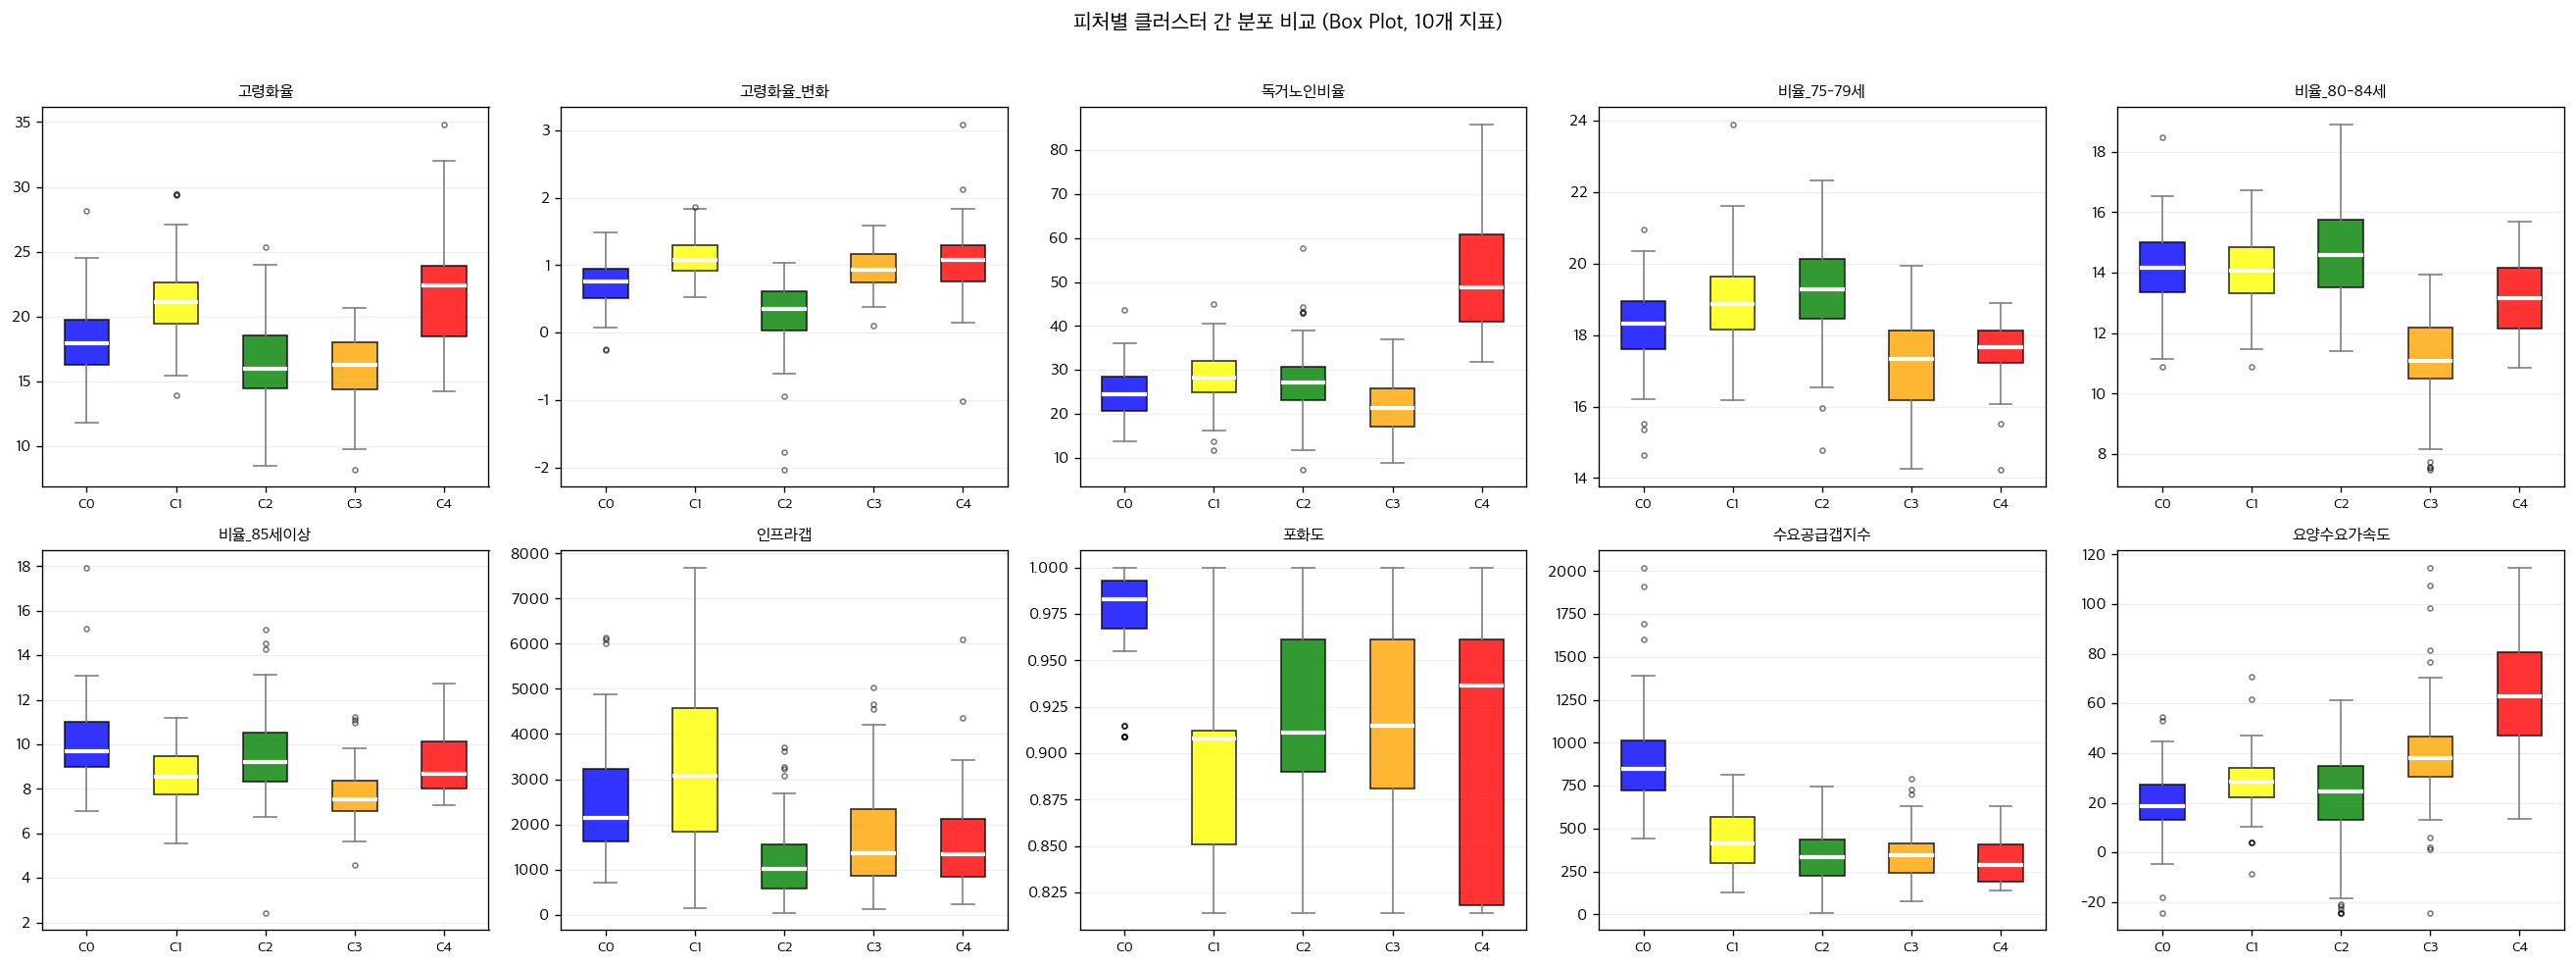

In [23]:
# Box Plot — 피처별 클러스터 분포 (2×5 레이아웃)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
palette_dict = {cid: PALETTE[sorted_clusters.index(cid) % len(PALETTE)] for cid in range(K_OPTIMAL)}

for ax, feat in zip(axes, CLUSTER_FEATS):
    data_by_cluster = [df[df['cluster_km'] == cid][feat].values for cid in range(K_OPTIMAL)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
    for patch, cid in zip(bp['boxes'], range(K_OPTIMAL)):
        patch.set_facecolor(palette_dict.get(cid, 'blue'))
        patch.set_alpha(0.8)
    ax.set_xticklabels([f'C{cid}' for cid in range(K_OPTIMAL)], fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)

# 빈 서브플롯이 있으면 숨김
for ax in axes[len(CLUSTER_FEATS):]:
    ax.set_visible(False)

plt.suptitle('피처별 클러스터 간 분포 비교 (Box Plot, 10개 지표)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

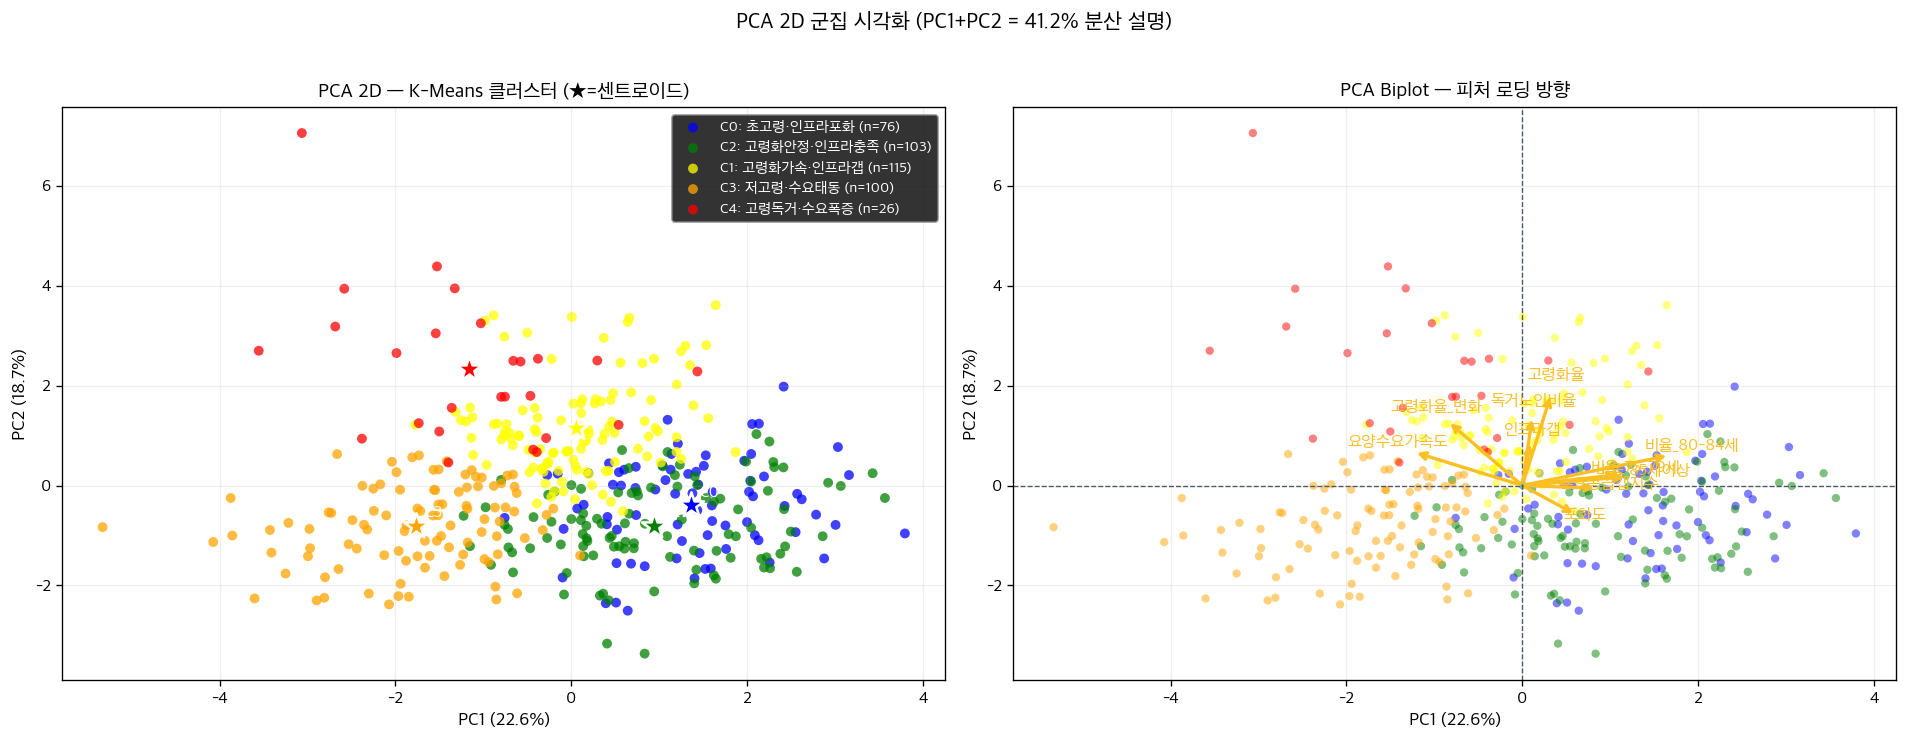

In [24]:
# PCA 2D 군집 시각화
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, cid in enumerate(sorted_clusters):
    mask = df['cluster_km'] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[i % len(PALETTE)], s=35, alpha=0.75, edgecolors='none',
               label=f'C{cid}: {cluster_names.get(cid,"")} (n={mask.sum()})')

centers_pca = pca.transform(km_final.cluster_centers_)
for i, cid in enumerate(range(K_OPTIMAL)):
    rank_i = sorted_clusters.index(cid)
    ax.scatter(centers_pca[cid, 0], centers_pca[cid, 1],
               c=PALETTE[rank_i % len(PALETTE)], s=250, marker='*',
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(f'C{cid}', (centers_pca[cid, 0], centers_pca[cid, 1]),
                fontsize=10, fontweight='bold', color='white', xytext=(5,5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)', fontsize=11)
ax.set_title('PCA 2D — K-Means 클러스터 (★=센트로이드)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='black', edgecolor='gray', labelcolor='white')
ax.grid(alpha=0.2)

# Biplot
ax2 = axes[1]
for i, cid in enumerate(sorted_clusters):
    mask = df['cluster_km'] == cid
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=PALETTE[i % len(PALETTE)], s=25, alpha=0.5, edgecolors='none')

loadings = pca.components_.T
scale = 3.0
for j, feat in enumerate(CLUSTER_FEATS):
    ax2.annotate('', xy=(loadings[j,0]*scale, loadings[j,1]*scale), xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=2))
    ax2.text(loadings[j,0]*scale*1.15, loadings[j,1]*scale*1.15,
             feat, fontsize=10, color='#fbbf24', fontweight='bold', ha='center')

ax2.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)', fontsize=11)
ax2.set_title('PCA Biplot — 피처 로딩 방향', fontsize=12, fontweight='bold')
ax2.axhline(0, color='#4b5563', lw=0.8, ls='--')
ax2.axvline(0, color='#4b5563', lw=0.8, ls='--')
ax2.grid(alpha=0.2)

plt.suptitle(f'PCA 2D 군집 시각화 (PC1+PC2 = {sum(var_ratio)*100:.1f}% 분산 설명)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 지도 시각화 (Folium)
### 5-1. GeoJSON 준비

In [25]:
with open('data/HangJeongDong_ver20260201.geojson', 'r', encoding='utf-8') as f:
    geojson_all = json.load(f)

geojson_seoul = {
    'type': 'FeatureCollection',
    'features': [
        feat for feat in geojson_all['features']
        if str(feat['properties'].get('adm_cd2', ''))[:2] == '11'
    ]
}
print(f'서울 행정동 GeoJSON: {len(geojson_seoul["features"])}개')

df['행정동코드_str'] = df['행정동코드'].astype(str)
map_info = df.set_index('행정동코드_str')[[
    '행정동명', 'cluster_km', 'cluster_label',
    '고령화율', '독거노인비율', '인프라갭', '포화도', '요양수요가속도'
]].copy()

matched = 0
for feat in geojson_seoul['features']:
    code = str(feat['properties'].get('adm_cd2', ''))
    if code in map_info.index:
        row = map_info.loc[code]
        props = feat['properties']
        props['cluster_km'] = int(row['cluster_km'])
        props['cluster_label'] = str(row['cluster_label'])
        props['dong_name'] = str(row['행정동명'])
        props['고령화율'] = round(float(row['고령화율']), 2)
        props['독거노인비율'] = round(float(row['독거노인비율']), 2)
        props['인프라갭'] = round(float(row['인프라갭']), 1)
        props['요양수요가속도'] = round(float(row['요양수요가속도']), 2)
        matched += 1
    else:
        feat['properties']['cluster_km'] = -1
        for k in ['cluster_label', 'dong_name']: feat['properties'][k] = '미분류'
        for k in ['고령화율', '독거노인비율', '인프라갭', '요양수요가속도']: feat['properties'][k] = 0.0

print(f'매칭: {matched}개 / 미매칭: {len(geojson_seoul["features"])-matched}개')

서울 행정동 GeoJSON: 427개
매칭: 419개 / 미매칭: 8개


### 5-2. K-Means 클러스터 지도

In [26]:
m_km = folium.Map(location=[37.555, 126.988], zoom_start=11, tiles='CartoDB dark_matter')

def style_km(feature):
    cid = feature['properties'].get('cluster_km', -1)
    if cid in sorted_clusters:
        color = PALETTE[sorted_clusters.index(cid) % len(PALETTE)]
    else:
        color = '#374151'
    return {'fillColor': color, 'color': '#0f1117', 'weight': 0.7, 'fillOpacity': 0.82}

def highlight_fn(feature):
    return {'weight': 2.5, 'color': 'white', 'fillOpacity': 0.95}

folium.GeoJson(
    geojson_seoul,
    style_function=style_km,
    highlight_function=highlight_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=['dong_name', 'cluster_label', '고령화율', '독거노인비율', '인프라갭', '요양수요가속도'],
        aliases=['행정동:', '클러스터:', '고령화율(%):', '독거노인비율(%):', '인프라갭:', '요양수요가속도:'],
        localize=True, sticky=True,
        style='background-color:#1e2230;color:#e2e8f0;font-size:12px;padding:8px;border-radius:4px;border:1px solid #3a4060;'
    )
).add_to(m_km)


# folium 라이브러리를 통해 HTML로 시각화
legend_items = ''.join([
    f"<div style='display:flex;align-items:center;gap:8px;margin:3px 0;'>"
    f"<div style='width:14px;height:14px;background:{PALETTE[i%len(PALETTE)]};border-radius:2px;flex-shrink:0;'></div>"
    f"<span style='font-size:11px;'>C{cid}: {cluster_names.get(cid,'')} ({cluster_sizes.get(cid,0)}개)</span></div>"
    for i, cid in enumerate(sorted_clusters)
])
legend_html = f"""
<div style='position:fixed;bottom:30px;left:30px;z-index:9999;background:#1e2230;border:1px solid #3a4060;
     border-radius:8px;padding:12px 16px;font-family:sans-serif;color:#e2e8f0;min-width:200px;'>
  <b style='font-size:13px;'>K-Means 클러스터 (K={K_OPTIMAL})</b>
  <div style='margin-top:6px;'>{legend_items}</div>
  <div style='margin-top:6px;font-size:10px;color:#94a3b8;'>마우스오버 시 상세 정보 표시</div>
</div>"""
m_km.get_root().html.add_child(folium.Element(legend_html))
m_km.save('data/map_kmeans_clusters.html')
print('저장: data/map_kmeans_clusters.html')
m_km

저장: data/map_kmeans_clusters.html


### 5-3. 요양수요가속도 Choropleth (참조용)

In [27]:
m_y = folium.Map(location=[37.555, 126.988], zoom_start=11, tiles='CartoDB dark_matter')

df_choro = df[['행정동코드_str', '요양수요가속도']].copy()
df_choro.columns = ['code', 'y_val']

folium.Choropleth(
    geo_data = geojson_seoul,
    data = df_choro,
    columns = ['code', 'y_val'],
    key_on = 'feature.properties.adm_cd2',
    fill_color = 'YlOrRd',
    fill_opacity = 0.85,
    line_opacity = 0.3,
    nan_fill_color ='#374151',
    legend_name ='요양수요가속도 [ln(독거노인_2023/2018) X 100]',
    bins=7
).add_to(m_y)

# folium 라이브러리를 통해 HTML로 시각화
folium.GeoJson(
    geojson_seoul,
    style_function=lambda x: {'fillColor':'transparent','color':'transparent','weight':0},
    tooltip=folium.GeoJsonTooltip(
        fields=['dong_name', '요양수요가속도', 'cluster_label'],
        aliases=['행정동:', '요양수요가속도:', 'K-Means 클러스터:'],
        localize=True, sticky=True,
        style='background-color:#1e2230;color:#e2e8f0;font-size:12px;padding:8px;border-radius:4px;'
    )
).add_to(m_y)

top10 = df.nlargest(10, '요양수요가속도')[['행정동명', '자치구명', '요양수요가속도', 'cluster_label']]
print('요양수요가속도 상위 10개 행정동:')
display(top10.reset_index(drop=True).round(2))

m_y.save('data/map_demand_acceleration.html')
print('\n저장: data/map_demand_acceleration.html')
m_y

요양수요가속도 상위 10개 행정동:


,행정동명,자치구명,요양수요가속도,cluster_label
0,하계2동,노원구,114.75,고령독거·수요폭증
1,상계2동,노원구,114.75,고령독거·수요폭증
2,상계9동,노원구,114.75,고령독거·수요폭증
3,상계10동,노원구,114.75,고령독거·수요폭증
4,가락1동,송파구,114.75,저고령·수요태동
5,위례동,송파구,107.36,저고령·수요태동
6,개포2동,강남구,98.35,저고령·수요태동
7,공릉2동,노원구,98.04,고령독거·수요폭증
8,수서동,강남구,93.18,고령독거·수요폭증
9,거여2동,송파구,82.09,고령독거·수요폭증



저장: data/map_demand_acceleration.html


---
## 6. 클러스터별 대표 행정동 & 종합 시각화

In [28]:
print('클러스터별 대표 행정동 (센트로이드 최근접 TOP 5)')
print('='*70)
for cid in range(K_OPTIMAL):
    mask = df['cluster_km'] == cid
    X_c = X_scaled[mask]
    center = km_final.cluster_centers_[cid].reshape(1, -1)
    dists = np.linalg.norm(X_c - center, axis=1)
    top5 = df[mask].iloc[np.argsort(dists)[:5]][['행정동명', '자치구명'] + CLUSTER_FEATS + ['요양수요가속도']]
    print(f'\n[C{cid}] {cluster_names.get(cid,"")} (n={mask.sum()})')
    display(top5.reset_index(drop=True).round(2))

print('\n클러스터별 요양수요가속도 통계:')
y_stats = df.groupby('cluster_km')['요양수요가속도'].agg(['mean','std','min','max','count']).round(3)
y_stats.index = [f'C{i}: {cluster_names.get(i,"")}' for i in y_stats.index]
display(y_stats)

클러스터별 대표 행정동 (센트로이드 최근접 TOP 5)

[C0] 초고령·인프라포화 (n=76)


,행정동명,자치구명,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,수요공급갭지수,요양수요가속도,요양수요가속도
0,대방동,동작구,15.82,0.45,24.59,18.08,13.96,10.36,1909.67,0.98,794.93,19.19,19.19
1,보광동,용산구,20.93,0.90,29.77,18.40,14.90,10.31,2657.00,0.98,1108.15,14.10,14.10
2,신길제6동,영등포구,18.42,0.95,23.82,17.57,13.07,9.00,1733.50,0.98,1071.65,14.99,14.99
3,중림동,중구,18.37,1.10,29.43,19.11,13.88,10.87,2202.00,1.00,919.78,30.64,30.64
4,합정동,마포구,16.10,0.76,25.29,19.27,15.12,10.38,1340.50,0.99,671.86,13.90,13.90



[C1] 고령화가속·인프라갭 (n=115)


,행정동명,자치구명,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,수요공급갭지수,요양수요가속도,요양수요가속도
0,난곡동,관악구,21.50,1.07,29.86,19.55,13.62,7.75,2801.50,0.91,626.92,27.95,27.95
1,석관동,성북구,21.88,1.20,26.51,19.81,14.54,8.08,3759.00,0.85,442.38,33.97,33.97
2,시흥제2동,금천구,21.08,1.54,23.88,18.81,13.46,8.53,4363.00,0.88,359.28,30.38,30.38
3,고척제2동,구로구,21.28,1.37,26.87,18.83,13.60,8.65,1853.67,0.91,491.16,41.76,41.76
4,창제2동,도봉구,19.40,1.05,23.34,18.65,14.08,8.50,1847.67,0.91,285.58,35.87,35.87



[C2] 고령화안정·인프라충족 (n=103)


...

,행정동명,자치구명,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,수요공급갭지수,요양수요가속도,요양수요가속도
0,방화제1동,강서구,16.68,1.03,19.28,16.91,11.11,8.07,1013.71,0.88,310.25,33.25,33.25
1,풍납2동,송파구,16.86,1.24,24.61,17.29,10.96,7.84,1357.33,0.96,414.84,32.22,32.22
2,성내제1동,강동구,16.40,0.66,18.11,17.44,10.70,7.63,537.33,0.90,245.93,32.96,32.96
3,둔촌제2동,강동구,17.74,0.81,21.20,17.19,10.30,8.01,1070.75,0.90,373.81,20.32,20.32
4,송파1동,송파구,15.36,0.71,24.13,16.47,10.91,7.58,726.00,0.96,316.28,47.64,47.64



[C4] 고령독거·수요폭증 (n=26)


,행정동명,자치구명,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,수요공급갭지수,요양수요가속도,요양수요가속도
0,창신제2동,종로구,23.86,1.84,51.88,18.17,14.18,9.00,1833.00,0.96,252.51,70.27,70.27
1,일원1동,강남구,22.99,1.00,46.88,17.66,11.38,8.57,3413.00,0.83,466.10,76.30,76.30
2,마천2동,송파구,23.47,1.52,40.13,18.06,13.19,8.38,842.80,0.96,371.07,46.61,46.61
3,하계1동,노원구,17.83,0.85,49.87,16.55,14.57,11.11,1579.33,0.81,396.19,64.24,64.24
4,풍납1동,송파구,22.82,1.50,36.63,18.23,12.54,7.26,1404.50,0.96,312.39,51.31,51.31



클러스터별 요양수요가속도 통계:


,mean,std,min,max,count
C0: 초고령·인프라포화,18.982,13.399,-24.336,54.590,76
C1: 고령화가속·인프라갭,28.101,10.816,-8.700,70.740,115
C2: 고령화안정·인프라충족,22.347,18.902,-24.336,61.380,103
C3: 저고령·수요태동,39.996,20.115,-24.336,114.752,100
C4: 고령독거·수요폭증,65.666,29.477,13.670,114.752,26


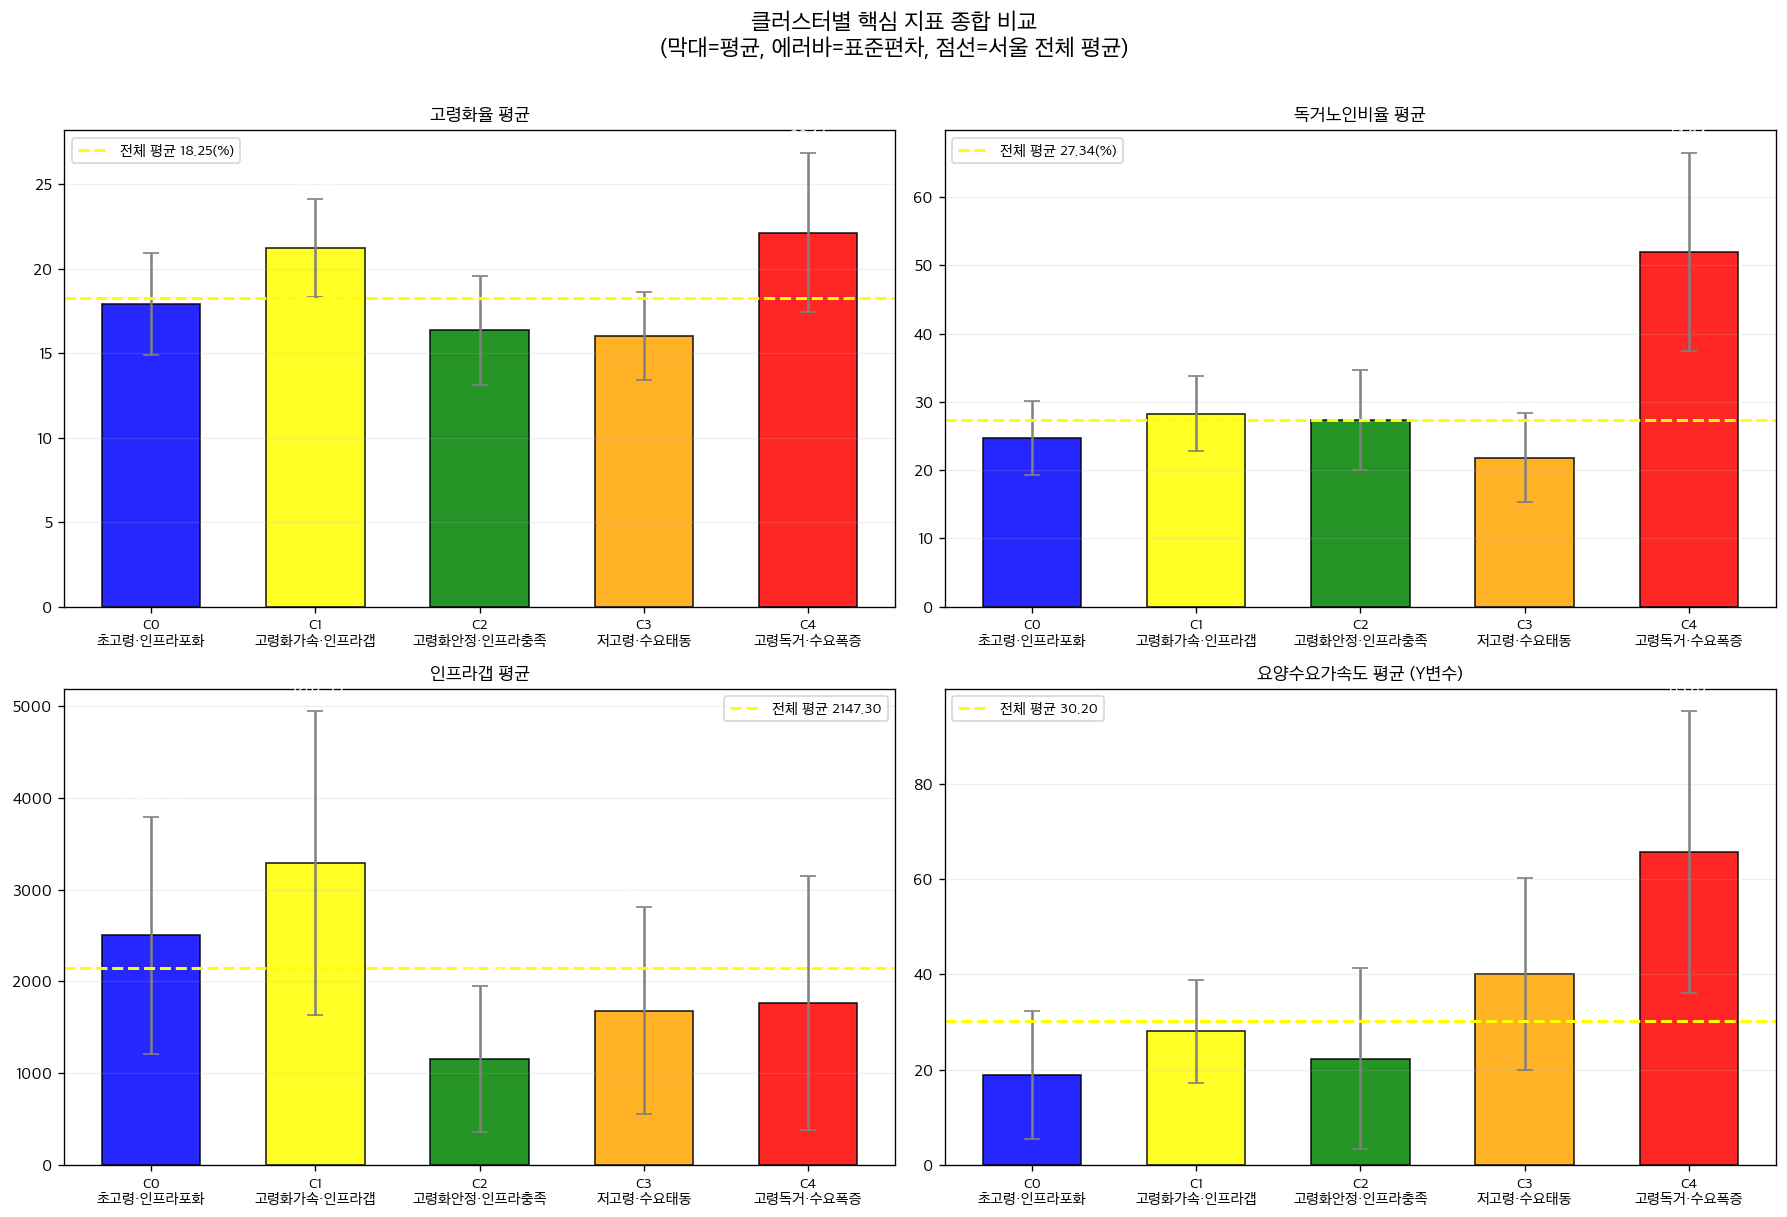

In [29]:
# 종합 대시보드
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

metrics = [
    ('고령화율', '(%)', '고령화율 평균'),
    ('독거노인비율', '(%)', '독거노인비율 평균'),
    ('인프라갭', '', '인프라갭 평균'),
    ('요양수요가속도', '', '요양수요가속도 평균 (Y변수)'),
]

x_pos = np.arange(K_OPTIMAL)
bar_colors = [PALETTE[sorted_clusters.index(cid) % len(PALETTE)] for cid in range(K_OPTIMAL)]
xlabels = [f'C{cid}\n{cluster_names.get(cid,"")}' for cid in range(K_OPTIMAL)]

for ax, (feat, unit, title) in zip(axes, metrics):
    means = [df[df['cluster_km']==cid][feat].mean() for cid in range(K_OPTIMAL)]
    stds  = [df[df['cluster_km']==cid][feat].std()  for cid in range(K_OPTIMAL)]
    ax.bar(x_pos, means, color=bar_colors, edgecolor='black', alpha=0.85, width=0.6,
           yerr=stds, capsize=5, error_kw={'ecolor':'gray','lw':1.5})
    overall = df[feat].mean()
    ax.axhline(overall, color='yellow', ls='--', lw=1.8, label=f'전체 평균 {overall:.2f}{unit}')
    for i, (v, s) in enumerate(zip(means, stds)):
        ax.text(i, v + s*1.1 + abs(max(means))*0.01, f'{v:.2f}',
                ha='center', fontsize=10, fontweight='bold', color='white')
    ax.set_xticks(x_pos); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)

plt.suptitle('클러스터별 핵심 지표 종합 비교\n(막대=평균, 에러바=표준편차, 점선=서울 전체 평균)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. 최종 결과 요약

### K-Means 군집화 결과
| 항목 | 내용 |
|------|------|
| 최적 K | 실루엣 점수 기준 자동 선정 (최소 3개 집단 보장) |
| 군집 피처 | 고령화율 · 독거노인비율 · 인프라갭 · 고령화율_변화 |
| 전처리 | StandardScaler (Z-score 표준화) |
| 클러스터 해석 | 취약도 합성 점수 기반 저취약 → 고취약 순 명명 |

### 분석 결론
- K-Means 군집화를 통해 행정동을 균형 있게 분류하여 **정책 우선순위 지정**에 활용 가능
- 클러스터별 취약도 프로파일을 바탕으로 **고위험 행정동**을 최우선 정책 대상으로 권장

### 생성된 지도 파일
| 파일 | 내용 |
|------|------|
| `data/map_kmeans_clusters.html` | K-Means 클러스터 인터랙티브 지도 |
| `data/map_demand_acceleration.html` | 요양수요가속도 Choropleth 지도 |